In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/content/SHOP_2015-05-21_2025-03-16.csv")

In [5]:
print(df.head())

                        date   open   high    low  close  adj_close     volume
0  2015-05-21 00:00:00-04:00  2.800  2.874  2.411  2.568      2.568  123039000
1  2015-05-22 00:00:00-04:00  2.607  3.110  2.600  2.831      2.831   28412000
2  2015-05-26 00:00:00-04:00  2.980  3.034  2.908  2.965      2.965    8202000
3  2015-05-27 00:00:00-04:00  3.067  3.081  2.700  2.750      2.750    7976000
4  2015-05-28 00:00:00-04:00  2.755  2.774  2.648  2.745      2.745    4000000


In [6]:
print(df.shape)

(2469, 7)


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2469 entries, 0 to 2468
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       2469 non-null   object 
 1   open       2469 non-null   float64
 2   high       2469 non-null   float64
 3   low        2469 non-null   float64
 4   close      2469 non-null   float64
 5   adj_close  2469 non-null   float64
 6   volume     2469 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 135.2+ KB
None


In [8]:
print(df.isnull().sum())

date         0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64


In [9]:
df["date"] = pd.to_datetime(
    df["date"],
    format="mixed",
     errors="coerce"
)

/tmp/ipykernel_3241/2989001025.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["date"] = pd.to_datetime(


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2469 entries, 0 to 2468
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       2469 non-null   object 
 1   open       2469 non-null   float64
 2   high       2469 non-null   float64
 3   low        2469 non-null   float64
 4   close      2469 non-null   float64
 5   adj_close  2469 non-null   float64
 6   volume     2469 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 135.2+ KB


In [11]:
df=df.sort_values("date")

In [12]:
df=df.set_index("date")

In [13]:
df=df.dropna()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2469 entries, 2015-05-21 00:00:00-04:00 to 2025-03-14 00:00:00-04:00
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   open       2469 non-null   float64
 1   high       2469 non-null   float64
 2   low        2469 non-null   float64
 3   close      2469 non-null   float64
 4   adj_close  2469 non-null   float64
 5   volume     2469 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 135.0+ KB


In [15]:
df["Daily_Price_Change"]=df["close"]-df["open"]

In [16]:
df["Daily_Return_%"]=(df["close"]-df["open"])/df["open"]*100

In [17]:
df["Price_Range"]=df["high"]-df["low"]

In [18]:
print(df.head())

                            open   high    low  close  adj_close     volume  \
date                                                                          
2015-05-21 00:00:00-04:00  2.800  2.874  2.411  2.568      2.568  123039000   
2015-05-22 00:00:00-04:00  2.607  3.110  2.600  2.831      2.831   28412000   
2015-05-26 00:00:00-04:00  2.980  3.034  2.908  2.965      2.965    8202000   
2015-05-27 00:00:00-04:00  3.067  3.081  2.700  2.750      2.750    7976000   
2015-05-28 00:00:00-04:00  2.755  2.774  2.648  2.745      2.745    4000000   

                           Daily_Price_Change  Daily_Return_%  Price_Range  
date                                                                        
2015-05-21 00:00:00-04:00              -0.232       -8.285710        0.463  
2015-05-22 00:00:00-04:00               0.224        8.592250        0.510  
2015-05-26 00:00:00-04:00              -0.015       -0.503359        0.126  
2015-05-27 00:00:00-04:00              -0.317      -10.335830

In [19]:
print(df.describe())

              open         high          low        close    adj_close  \
count  2469.000000  2469.000000  2469.000000  2469.000000  2469.000000   
mean     48.464345    49.505495    47.347795    48.456613    48.456613   
std      43.633916    44.470235    42.642546    43.573362    43.573362   
min       1.939000     1.985000     1.848000     1.933000     1.933000   
25%      10.479000    10.635000    10.275000    10.450000    10.450000   
50%      35.640999    36.879002    34.655998    35.874001    35.874001   
75%      76.080002    77.169998    74.589996    75.800003    75.800003   
max     171.800003   176.291794   168.509506   169.059998   169.059998   

             volume  Daily_Price_Change  Daily_Return_%  Price_Range  
count  2.469000e+03         2469.000000     2469.000000  2469.000000  
mean   1.657049e+07           -0.007732        0.086406     2.157700  
std    1.436909e+07            1.949302        3.119789     2.319697  
min    1.039000e+06          -13.463997      -12.

In [20]:
print("Mean Return:",df["Daily_Return_%"].mean())

Mean Return: 0.08640631099421993


In [21]:
print("Return_Variance:",df["Daily_Return_%"].var())

Return_Variance: 9.733081984179565


In [22]:
print("Return_Standard_Variation:",df["Daily_Return_%"].std())

Return_Standard_Variation: 3.1197887723657773


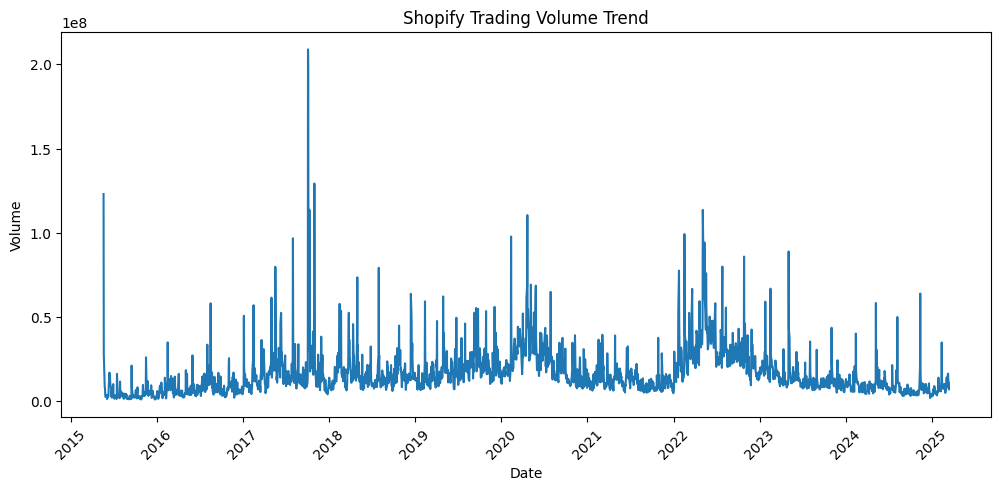

In [23]:
# 15. Volume trend
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["volume"])
plt.title("Shopify Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.show()

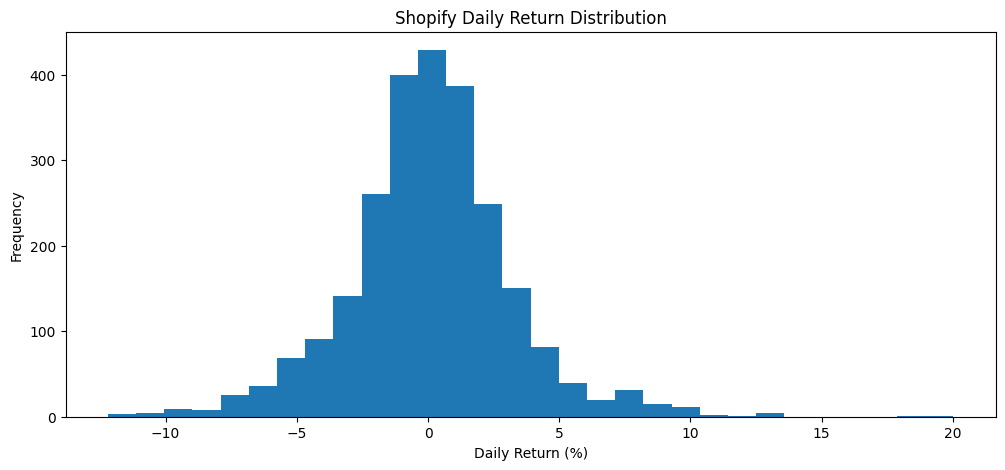

In [24]:
plt.figure(figsize=(12,5))
plt.hist(df["Daily_Return_%"], bins=30)
plt.title("Shopify Daily ""Return Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.show()